# **Student Performance Predictor**

## Objective
Predict student academic performance using:
- Logistic Regression
- SVM
- Random Forest
- MLP Neural Network

## Workflow
1. Data Loading
2. Exploratory Data Analysis
3. Preprocessing
4. Feature Engineering
5. Model Training
6. Evaluation
7. Model Comparison

In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
import os

base_path = "/content/drive/MyDrive/Student_Performance_Predictor"

folders = ["data", "outputs", "models"]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [72]:
print(os.listdir(base_path))

['data', 'outputs', 'models']


## **Importing All Required Libraries**


*   List item
*   List item



In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import(
    train_test_split,
    cross_val_score,
    learning_curve
)

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Setting Plotting Defaults




In [74]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

Verifying Tensorflow version

In [75]:
print("Tensorflow version: ", tf.__version__)

Tensorflow version:  2.20.0


## **Data Loading and Initial Inspection**

In [76]:
file_path = "/content/drive/MyDrive/Student_Performance_Predictor/data/student-mat.csv"
df = pd.read_csv(file_path, sep=';')

In [77]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [78]:
print("Shape:", df.shape)

Shape: (395, 33)


In [79]:
df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [81]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [82]:
missing = df.isnull().sum()
missing[missing > 0]

,0


In [83]:
print('Duplicated rows:', df.duplicated().sum())

Duplicated rows: 0


In [84]:
df[['G3','G2','G1']].head()

,G3,G2,G1
0,6,6,5
1,6,5,5
2,10,8,7
3,15,14,15
4,10,10,6


In [85]:
for col in df.select_dtypes(include='object').columns:
  print(f"{col}: {df[col].unique()}")
  print("-" *40)


school: ['GP' 'MS']
----------------------------------------
sex: ['F' 'M']
----------------------------------------
address: ['U' 'R']
----------------------------------------
famsize: ['GT3' 'LE3']
----------------------------------------
Pstatus: ['A' 'T']
----------------------------------------
Mjob: ['at_home' 'health' 'other' 'services' 'teacher']
----------------------------------------
Fjob: ['teacher' 'other' 'services' 'health' 'at_home']
----------------------------------------
reason: ['course' 'other' 'home' 'reputation']
----------------------------------------
guardian: ['mother' 'father' 'other']
----------------------------------------
schoolsup: ['yes' 'no']
----------------------------------------
famsup: ['no' 'yes']
----------------------------------------
paid: ['no' 'yes']
----------------------------------------
activities: ['no' 'yes']
----------------------------------------
nursery: ['yes' 'no']
----------------------------------------
higher: ['yes' 'no']
-

### **Initial Observations**

- Dataset contains 395 student records
- 33 features
- Mix of categorical and numerical columns
- No missing values
- Final grade column G3 likely target variable
- Small tabular dataset, likely favorable for tree-based models

## **Machine Learning Concepts**

### *Supervised Learning*

Supervised learning is a machine learning approach where a model learns patterns from labeled data.

- Input features are represented as **X**
- Output labels/targets are represented as **y**

The goal is to learn a mapping:

y = f(X)

For this project:

- X = student-related features such as study time, absences, failures, family support, etc.
- y = student performance outcome

The model learns from historical student records and predicts future outcomes.

---

### *Classification*

Classification is used when the output belongs to a category.

This project will use **binary classification**.

Possible target classes:

- 1 = Pass
- 0 = Fail

Instead of predicting exact marks, the model predicts whether a student is likely to pass or fail.

---

### *Train-Test Split*

Machine learning models must generalize to unseen data.

The dataset is split into:

- Training set: used to learn patterns
- Test set: used to evaluate model performance on unseen data

This prevents the model from simply memorizing the dataset.

Typical split:
- 80% training
- 20% testing


---

### *Overfitting vs Underfitting*

A good model should generalize well.

#### Underfitting
Occurs when the model is too simple.

Symptoms:
- Poor training performance
- Poor testing performance

Example:
- Logistic Regression may underfit complex patterns.

#### Overfitting
Occurs when the model memorizes training data.

Symptoms:
- Very high training accuracy
- Low testing accuracy

Example:
- Deep neural networks can overfit small datasets.

Goal:
Balance both.

---

### *Bias-Variance Tradeoff*

Bias = error due to overly simple assumptions.

Variance = error due to sensitivity to training data.

High bias:
- Model too simple
- Underfitting

High variance:
- Model too complex
- Overfitting

Goal:
Find a balance between bias and variance.

---
---

## **Evaluation Metrics**

### *Confusion Matrix*

A confusion matrix summarizes classification results.
- True Positive (TP): correctly predicted positive
- True Negative (TN): correctly predicted negative
- False Positive (FP): predicted positive but actually negative
- False Negative (FN): predicted negative but actually positive
<br>

For this project:

Positive = Pass  
Negative = Fail

Examples:

- TP: Predicted pass, actually pass

- TN: Predicted fail, actually fail

- FP: Predicted pass, actually fail

- FN:Predicted fail, actually pass

---
### *Accuracy*

Accuracy measures the proportion of correct predictions.
Formula: Accuracy = (TP + TN) / Total Predictions

---
### *Precision*

Precision answers Of all predicted positive cases, how many were correct?

Formula: Precision = TP / (TP + FP)

High precision means fewer false positives.

---

### *Recall*

Recall answers: Of all actual positive cases, how many were identified?

Formula: Recall = TP / (TP + FN)

High recall means fewer false negatives.

---

### *F1 Score*

F1 Score is the harmonic mean of precision and recall.

Formula: F1 = 2 × (Precision × Recall) / (Precision + Recall)

F1 is useful when balancing precision and recall is important.

---

### *Cross Validation*

Cross validation evaluates model stability.

Instead of one train-test split:

- Split dataset multiple times
- Train and validate repeatedly

This project will use: 5-fold cross validation

---

### *Learning Curves*

Learning curves show:

- Training performance
- Validation performance

as dataset size increases.

Used to diagnose:

- Overfitting
- Underfitting
- Data sufficiency

---
---


## Exploratory Data Analysis (EDA)

### **Feature Understanding and Target Analysis**

In [86]:
for i,col in enumerate(df.columns,1):
  print(f"{i}. {col}")

1. school
2. sex
3. age
4. address
5. famsize
6. Pstatus
7. Medu
8. Fedu
9. Mjob
10. Fjob
11. reason
12. guardian
13. traveltime
14. studytime
15. failures
16. schoolsup
17. famsup
18. paid
19. activities
20. nursery
21. higher
22. internet
23. romantic
24. famrel
25. freetime
26. goout
27. Dalc
28. Walc
29. health
30. absences
31. G1
32. G2
33. G3


In [87]:
categorical_cols=df.select_dtypes(include='object').columns.tolist()
numerical_cols=df.select_dtypes(exclude='object').columns.tolist()

print('Categorical Columns:')
print(categorical_cols)
print('\nNumerical Columns:')
print(numerical_cols)

Categorical Columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical Columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [88]:
print('Number of Categorical columns: ',len(categorical_cols))
print('Number of Numerical columns: ',len(numerical_cols))

Number of Categorical columns:  17
Number of Numerical columns:  16


In [89]:
df[['G1','G2','G3']].describe()

,G1,G2,G3
count,395.000000,395.000000,395.000000
mean,10.908861,10.713924,10.415190
std,3.319195,3.761505,4.581443
min,3.000000,0.000000,0.000000
25%,8.000000,9.000000,8.000000
50%,11.000000,11.000000,11.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,20.000000


G3 distribution

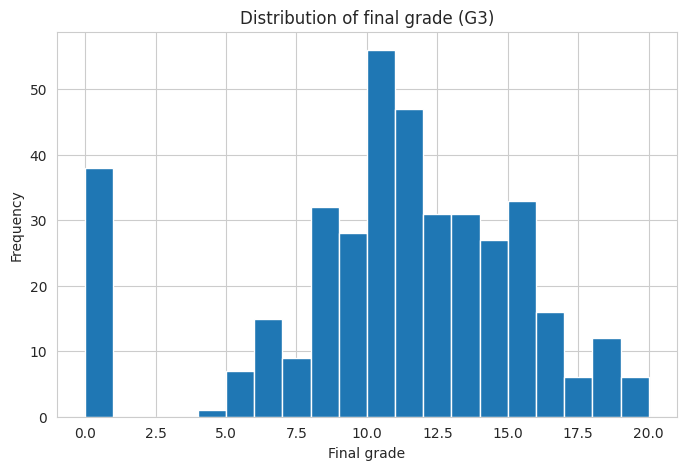

In [90]:
plt.hist(df['G3'], bins=20)
plt.title('Distribution of final grade (G3)')
plt.xlabel('Final grade')
plt.ylabel('Frequency')
plt.show()

In [91]:
print(df['G3'].value_counts().sort_index())

G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64


Binary Target

In [92]:
df['pass']=(df['G3']>=10).astype(int)
df[['G3','pass']].head()

,G3,pass
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1


In [93]:
df['pass'].value_counts()

,count
pass,
1,265
0,130


In [94]:
df['pass'].value_counts(normalize=True)*100

,proportion
pass,
1,67.088608
0,32.911392


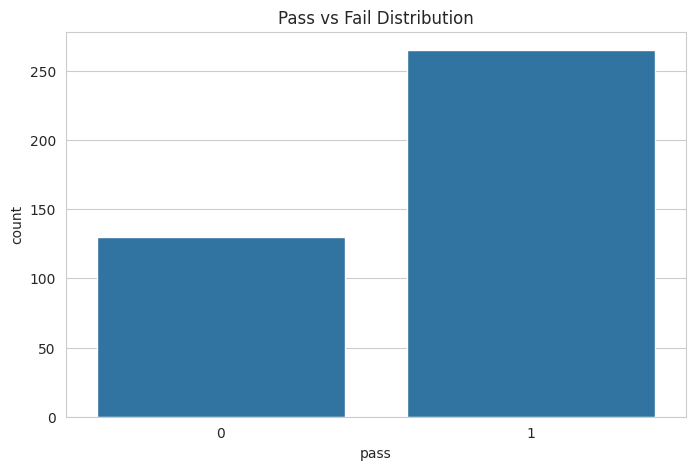

In [95]:
sns.countplot(x='pass', data=df)
plt.title('Pass vs Fail Distribution')
plt.show()

### Initial EDA Observations

- Target variable chosen: G3 converted into binary pass/fail
- Pass threshold: G3 >= 10
- Dataset contains both categorical and numerical features
- Class balance was inspected to detect imbalance
- Grade distribution was visualized before modeling

Potential data leakage concern:

- G1 and G2 are previous grades and may strongly predict G3.

Future experiment: compare models with and without G1/G2.

### Class Distribution Observation

The dataset shows mild class imbalance:

- Pass: approximately 67%
- Fail: approximately 33%

Implications:
- Accuracy alone is insufficient
- F1 score is a more reliable primary metric
- A baseline dummy classifier will be used for comparison

### Feature Leakage Consideration

Features G1 and G2 are previous grades and are likely strong predictors of final grade G3.

Two experiments will be conducted:

1. Train models using all features
2. Train models excluding G1 and G2

Purpose:
- measure dependence on previous grades
- evaluate predictive power of other features

### **Data Quality Checks**

In [96]:
missing_values=df.isnull().sum()
missing_values[missing_values > 0]

,0


#### Missing Values Analysis

Checked all columns for null values.

Observation:
- No missing values detected

Implication:
- No imputation required for this dataset

In [97]:
duplicates=df.duplicated().sum()
print('Duplicate rows: ', duplicates)

Duplicate rows:  0


#### Duplicate Analysis

Checked for duplicate student records.

Observation:
- No duplicate rows detected

### Numerical Feature Distributions

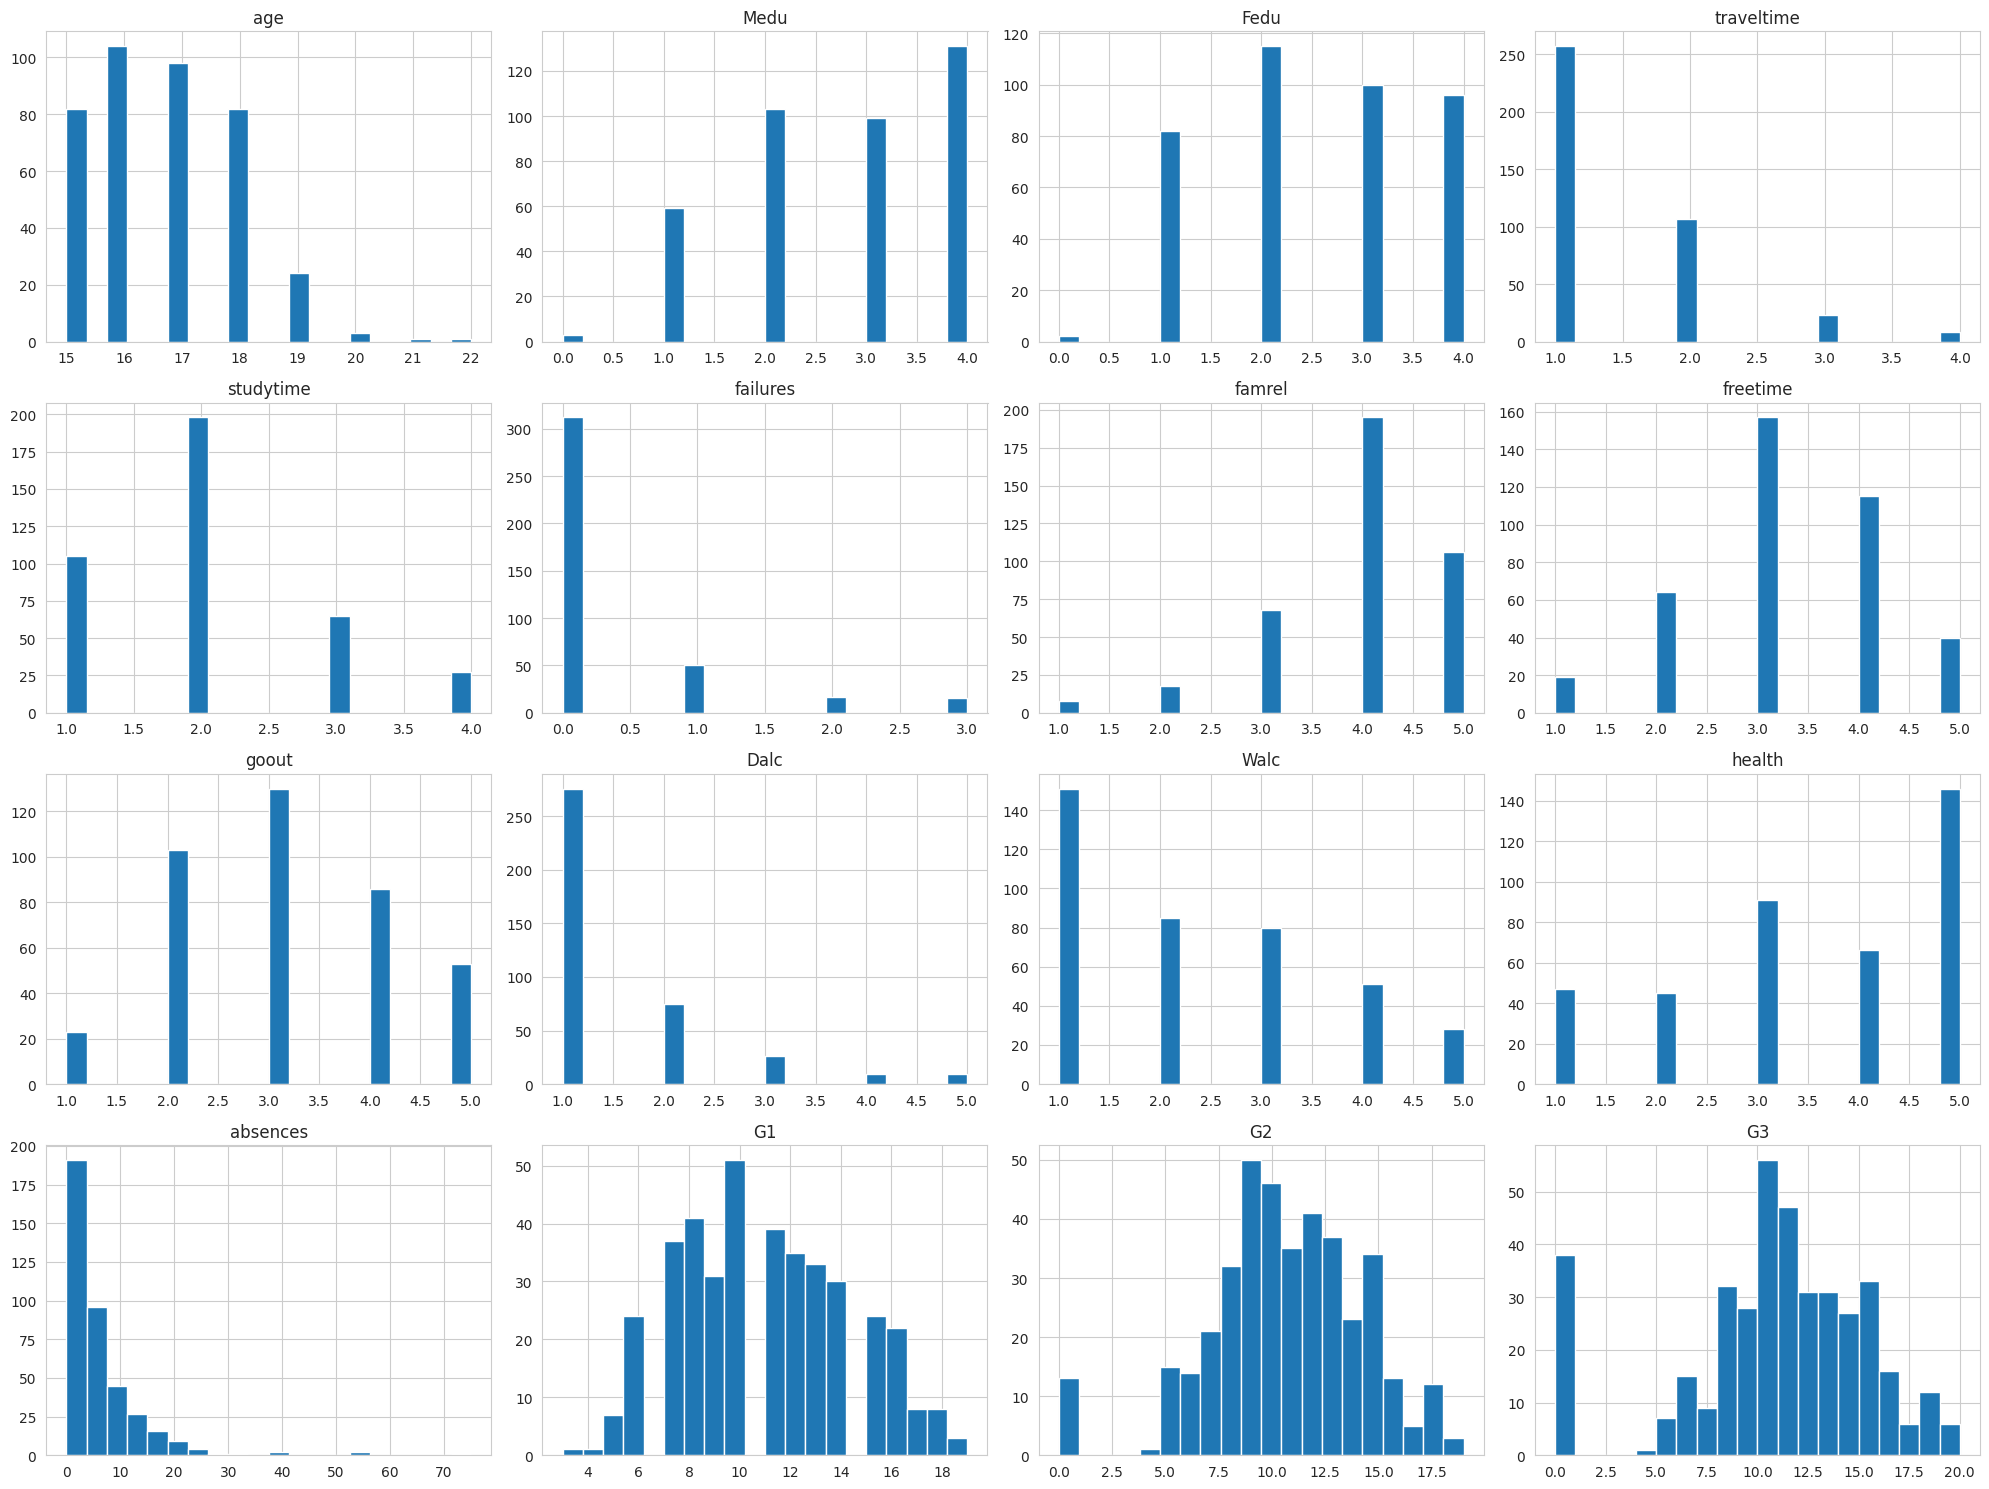

In [98]:
df[numerical_cols].hist(figsize=(20,15), bins=20)
plt.tight_layout()
plt.show()

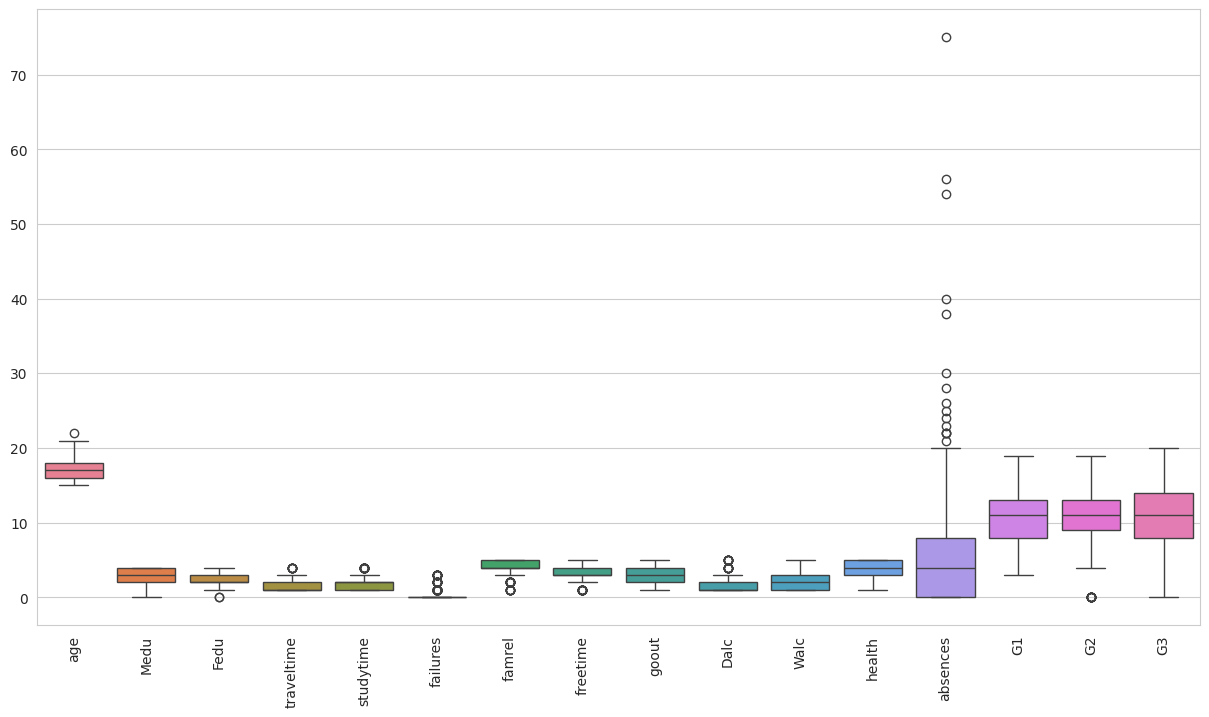

In [99]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=90)
plt.show()

#### Outlier Analysis

Boxplots were used to inspect numerical features.

Potential outliers observed in:
- absences

Observation:
- most numerical features appear reasonable
- absences may contain extreme values

In [100]:
df['absences'].describe()

,absences
count,395.000000
mean,5.708861
std,8.003096
min,0.000000
25%,0.000000
50%,4.000000
75%,8.000000
max,75.000000


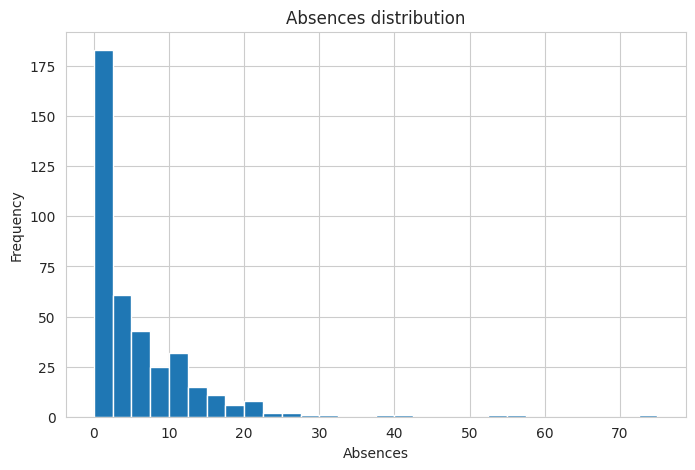

In [101]:
plt.hist(df['absences'], bins=30)
plt.title('Absences distribution')
plt.xlabel('Absences')
plt.ylabel('Frequency')
plt.show()

#### Absences Observation

Absences show a right-skewed distribution.

Interpretation:
- most students have relatively low absences
- a small number have very high absences

In [102]:
df['failures'].value_counts().sort_index()

,count
failures,
0,312
1,50
2,17
3,16


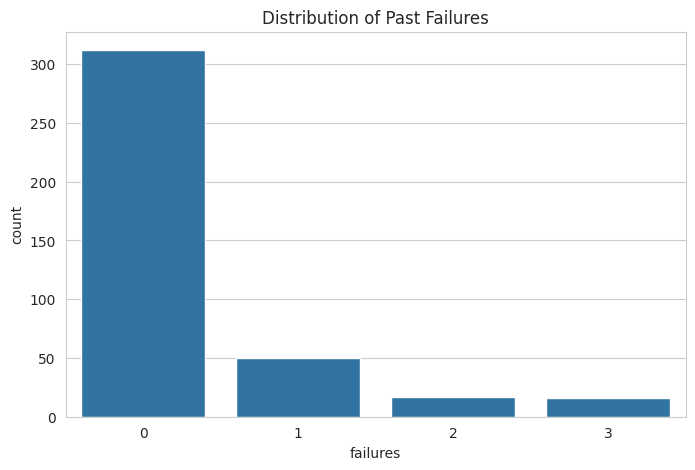

In [103]:
sns.countplot(x='failures', data=df)
plt.title("Distribution of Past Failures")
plt.show()

#### Failures Observation

Most students have low or zero past failures.

This feature may strongly correlate with academic performance.

### Summary

Findings:
- Dataset quality checked
- Missing values inspected
- Duplicate rows checked
- Numerical feature distributions visualized
- Outliers inspected using boxplots

Potentially informative features observed:
- absences
- failures
- studytime

### **Feature Relationships with Target Variable**

In [104]:
correlation_matrix=df[numerical_cols + ['pass']].corr()
correlation_matrix

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
age,1.000000,-0.163658,-0.163438,0.070641,-0.004140,0.243665,0.053940,0.016434,0.126964,0.131125,0.117276,-0.062187,0.175230,-0.064081,-0.143474,-0.161579,-0.179645
Medu,-0.163658,1.000000,0.623455,-0.171639,0.064944,-0.236680,-0.003914,0.030891,0.064094,0.019834,-0.047123,-0.046878,0.100285,0.205341,0.215527,0.217147,0.115396
Fedu,-0.163438,0.623455,1.000000,-0.158194,-0.009175,-0.250408,-0.001370,-0.012846,0.043105,0.002386,-0.012631,0.014742,0.024473,0.190270,0.164893,0.152457,0.108057
traveltime,0.070641,-0.171639,-0.158194,1.000000,-0.100909,0.092239,-0.016808,-0.017025,0.028540,0.138325,0.134116,0.007501,-0.012944,-0.093040,-0.153198,-0.117142,-0.044446
studytime,-0.004140,0.064944,-0.009175,-0.100909,1.000000,-0.173563,0.039731,-0.143198,-0.063904,-0.196019,-0.253785,-0.075616,-0.062700,0.160612,0.135880,0.097820,0.074613
failures,0.243665,-0.236680,-0.250408,0.092239,-0.173563,1.000000,-0.044337,0.091987,0.124561,0.136047,0.141962,0.065827,0.063726,-0.354718,-0.355896,-0.360415,-0.337731
famrel,0.053940,-0.003914,-0.001370,-0.016808,0.039731,-0.044337,1.000000,0.150701,0.064568,-0.077594,-0.113397,0.094056,-0.044354,0.022168,-0.018281,0.051363,0.046683
freetime,0.016434,0.030891,-0.012846,-0.017025,-0.143198,0.091987,0.150701,1.000000,0.285019,0.209001,0.147822,0.075733,-0.058078,0.012613,-0.013777,0.011307,-0.018321
goout,0.126964,0.064094,0.043105,0.028540,-0.063904,0.124561,0.064568,0.285019,1.000000,0.266994,0.420386,-0.009577,0.044302,-0.149104,-0.162250,-0.132791,-0.183399
Dalc,0.131125,0.019834,0.002386,0.138325,-0.196019,0.136047,-0.077594,0.209001,0.266994,1.000000,0.647544,0.077180,0.111908,-0.094159,-0.064120,-0.054660,-0.057343


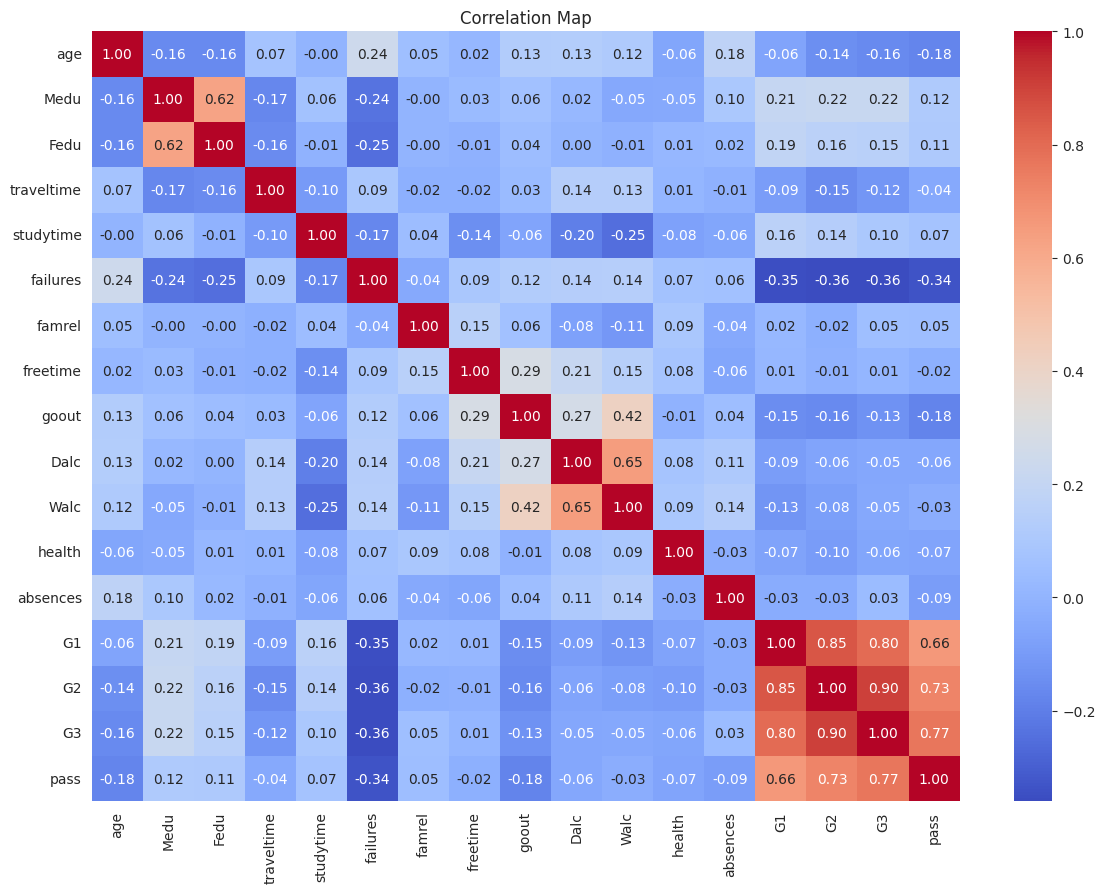

In [105]:
plt.figure(figsize=(14,10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Map')
plt.show()

In [106]:
target_corr=correlation_matrix['pass'].sort_values(ascending=False)
print(target_corr)

pass          1.000000
G3            0.770042
G2            0.725407
G1            0.664979
Medu          0.115396
Fedu          0.108057
studytime     0.074613
famrel        0.046683
freetime     -0.018321
Walc         -0.029957
traveltime   -0.044446
Dalc         -0.057343
health       -0.065668
absences     -0.092244
age          -0.179645
goout        -0.183399
failures     -0.337731
Name: pass, dtype: float64


#### Correlation Observations

Features positively associated with passing:
- G1
- G2
- G3

Features negatively associated with passing:
- failures

G1 and G2 show especially strong correlation and may introduce leakage concerns.

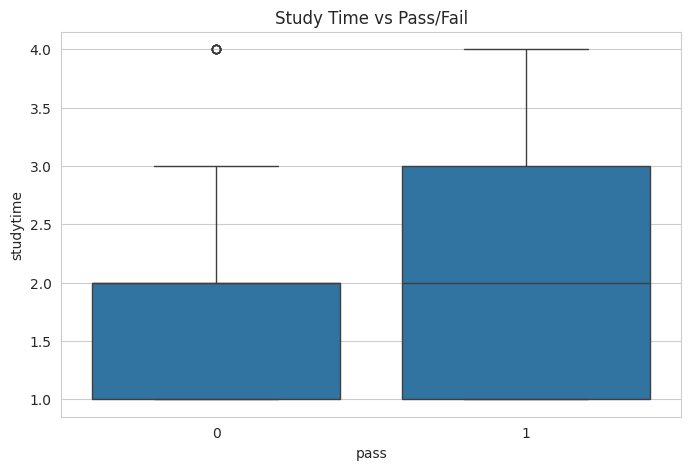

In [107]:
sns.boxplot(x='pass', y='studytime', data=df)
plt.title("Study Time vs Pass/Fail")
plt.show()

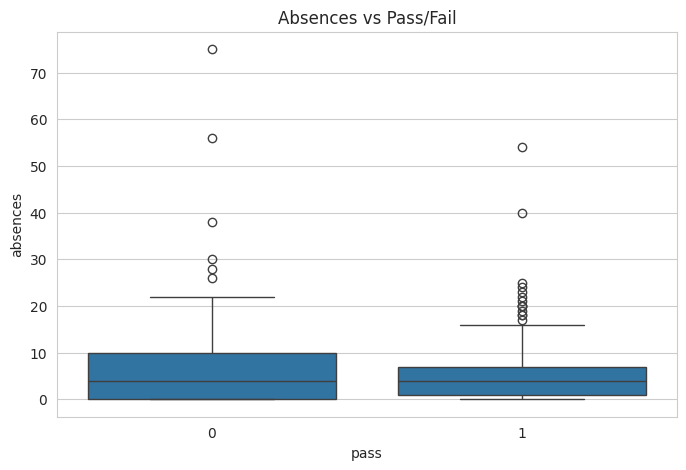

In [108]:
sns.boxplot(x='pass', y='absences', data=df)
plt.title("Absences vs Pass/Fail")
plt.show()

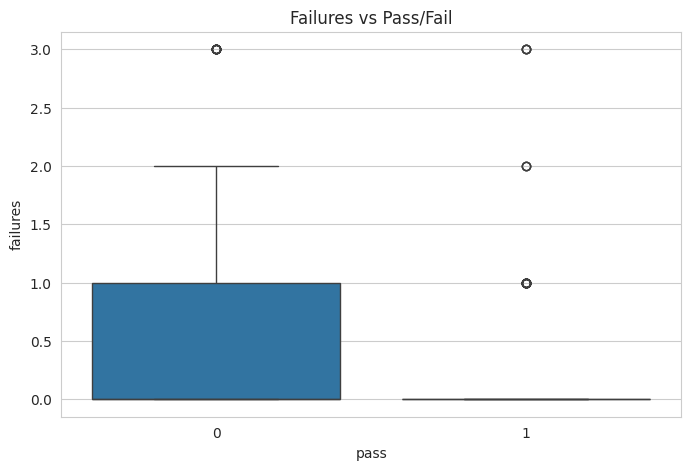

In [109]:
sns.boxplot(x='pass', y='failures', data=df)
plt.title("Failures vs Pass/Fail")
plt.show()

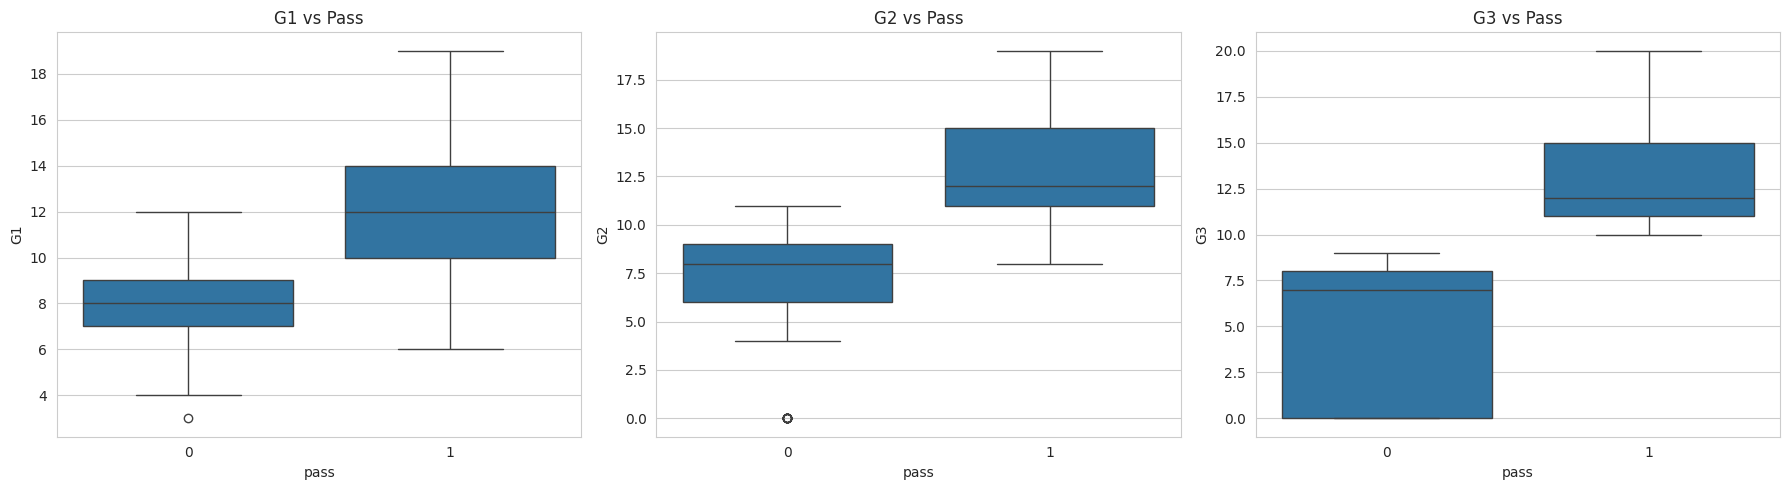

In [110]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(x='pass', y='G1', data=df, ax=axes[0])
axes[0].set_title("G1 vs Pass")

sns.boxplot(x='pass', y='G2', data=df, ax=axes[1])
axes[1].set_title("G2 vs Pass")

sns.boxplot(x='pass', y='G3', data=df, ax=axes[2])
axes[2].set_title("G3 vs Pass")

plt.tight_layout()
plt.show()

Categorical feature analysis

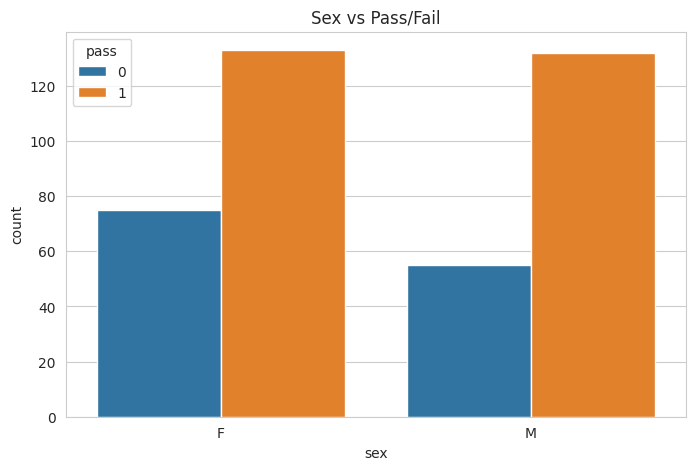

In [111]:
sns.countplot(x='sex', hue='pass', data=df)
plt.title("Sex vs Pass/Fail")
plt.show()

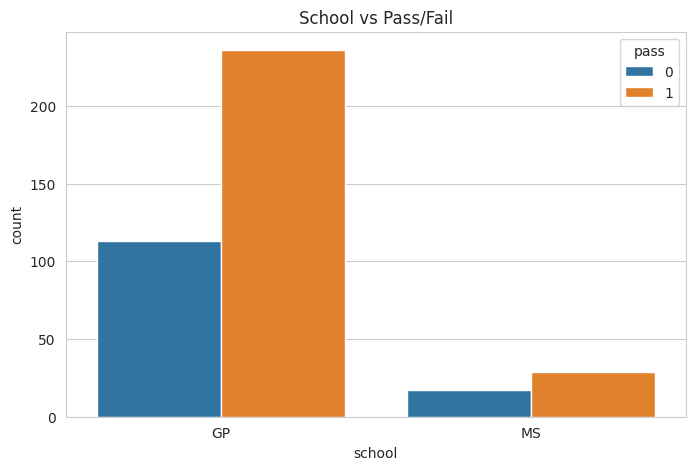

In [112]:
sns.countplot(x='school', hue='pass', data=df)
plt.title("School vs Pass/Fail")
plt.show()

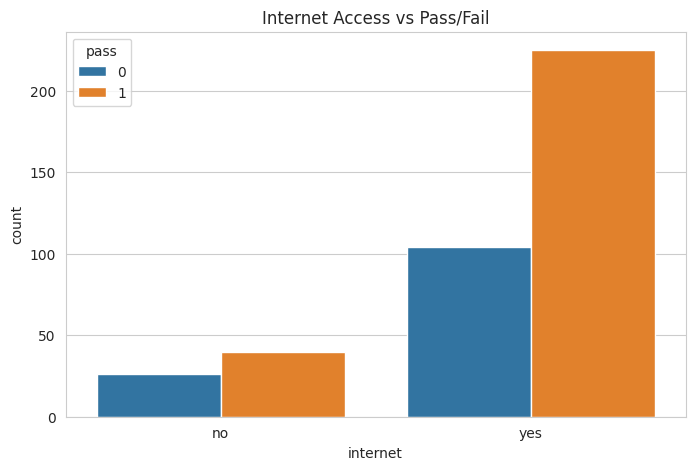

In [113]:
sns.countplot(x='internet', hue='pass', data=df)
plt.title("Internet Access vs Pass/Fail")
plt.show()

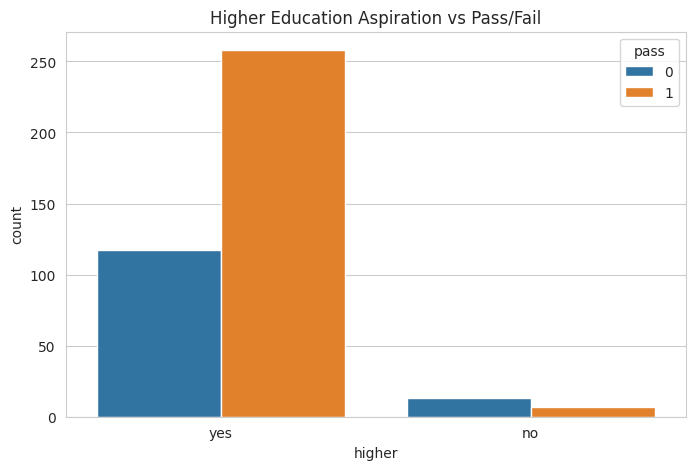

In [114]:
sns.countplot(x='higher', hue='pass', data=df)
plt.title("Higher Education Aspiration vs Pass/Fail")
plt.show()

### **Key Feature Insights**

Potential strong predictors:
- G1
- G2
- failures
- absences
- studytime

Observed trends:
- students with fewer failures tend to pass more often
- lower absences may be associated with passing
- previous grades strongly predict final performance
- higher education intention may align with passing

### Hypotheses Before Modeling

Hypothesis 1:
- Random Forest may perform well due to mixed feature types and nonlinear relationships.

Hypothesis 2:
- Logistic Regression may underperform if relationships are nonlinear.

Hypothesis 3:
- MLP may overfit due to small dataset size.

Hypothesis 4:
- Removing G1 and G2 will significantly reduce performance.

### Correlation Findings

Strong positive predictors of passing:
- G1
- G2
- higher (desire for higher education)
- internet access

Strong negative predictors of passing:
- failures

Notes:
- G3 was excluded from interpretation as it is directly used to create the target variable (pass/fail), making it a source of leakage.

### Interpretation

Academic history appears highly predictive:
- previous grades strongly influence final outcome

Behavioral and contextual factors also appear useful:
- failures
- higher education aspiration
- internet access

### **Final Exploratory Analysis and Preprocessing Planning**

In [115]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    print("-" * 40)


Column: school
school
GP    349
MS     46
Name: count, dtype: int64
----------------------------------------

Column: sex
sex
F    208
M    187
Name: count, dtype: int64
----------------------------------------

Column: address
address
U    307
R     88
Name: count, dtype: int64
----------------------------------------

Column: famsize
famsize
GT3    281
LE3    114
Name: count, dtype: int64
----------------------------------------

Column: Pstatus
Pstatus
T    354
A     41
Name: count, dtype: int64
----------------------------------------

Column: Mjob
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64
----------------------------------------

Column: Fjob
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64
----------------------------------------

Column: reason
reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64
-

#### Categorical Feature Observations

Most categorical features are low-cardinality.

Many are binary:
- sex
- schoolsup
- internet
- nursery
- activities
- paid
- famsup
- schoolsup
- higher
- romantic

Some contain multiple categories:
- guardian
- Mjob
- Fjob
- reason

In [116]:
for col in categorical_cols:
    print(col, ":", df[col].nunique())

school : 2
sex : 2
address : 2
famsize : 2
Pstatus : 2
Mjob : 5
Fjob : 5
reason : 4
guardian : 3
schoolsup : 2
famsup : 2
paid : 2
activities : 2
nursery : 2
higher : 2
internet : 2
romantic : 2


#### Encoding Consideration

Categorical features have relatively low cardinality.

Implication:
- one-hot encoding is feasible without large dimensional expansion.

In [117]:
ordinal_cols = ['studytime', 'failures', 'famrel', 'freetime', 'goout', 'health']

for col in ordinal_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


studytime
studytime
1    105
2    198
3     65
4     27
Name: count, dtype: int64

failures
failures
0    312
1     50
2     17
3     16
Name: count, dtype: int64

famrel
famrel
1      8
2     18
3     68
4    195
5    106
Name: count, dtype: int64

freetime
freetime
1     19
2     64
3    157
4    115
5     40
Name: count, dtype: int64

goout
goout
1     23
2    103
3    130
4     86
5     53
Name: count, dtype: int64

health
health
1     47
2     45
3     91
4     66
5    146
Name: count, dtype: int64


#### Ordinal Features

Some numerical columns represent ordered categories rather than continuous values.

Examples:
- studytime
- failures
- famrel
- freetime
- goout
- health

These features retain meaningful order.

In [118]:
binary_features = []
multiclass_features = []

for col in categorical_cols:
    if df[col].nunique() == 2:
        binary_features.append(col)
    else:
        multiclass_features.append(col)

print("Binary categorical features:")
print(binary_features)

print("\nMulticlass categorical features:")
print(multiclass_features)

Binary categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Multiclass categorical features:
['Mjob', 'Fjob', 'reason', 'guardian']


### Planned Preprocessing Strategy

Binary categorical features:
- label encoding or one-hot encoding

Multiclass categorical features:
- one-hot encoding

Numerical features:
- scaling using StandardScaler

In [119]:
scaling_candidates = numerical_cols.copy()

print(scaling_candidates)

['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


#### Scaling Consideration

Feature scaling will be applied primarily for:

- SVM
- MLP

Reason:
These models are sensitive to feature magnitude.

Random Forest is generally scale-invariant.

### Leakage Considerations

Potential leakage features:
- G1
- G2

Reason:
These are previous grades and strongly correlate with final grade G3.

Experiments planned:

1. Models trained with G1 and G2 included
2. Models trained with G1 and G2 excluded

## **Summary**

Dataset characteristics:
- 395 rows
- 33 features
- mix of categorical and numerical variables

Data quality:
- no missing values
- no duplicate rows

Target:
- binary pass/fail derived from G3

Potential strong predictors:
- G1
- G2
- failures
- higher
- internet
- absences
- studytime

Potential concerns:
- feature leakage from G1 and G2
- outliers in absences

Planned preprocessing:
- one-hot encoding
- feature scaling
- train-test split

### Modeling Expectations

Expected strong performers:
- Random Forest
- SVM

Potential limitations:
- Logistic Regression may underfit
- MLP may overfit due to small dataset size

## **Data Preprocessing**

### Data Cleaning and Feature Separation

In [120]:
df_processed = df.copy()

A working copy of the dataset was created to preserve the original raw data.

In [121]:
df_processed[['G3', 'pass']].head()

,G3,pass
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1


In [122]:
y=df_processed['pass']

Target variable selected:

- pass (binary classification target derived from G3)

In [123]:
X_with_grades=df_processed.drop(columns=['G3','pass'])
X_with_grades.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,6,5,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,4,5,5
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,10,7,8
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,2,15,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,4,6,10


Experiment 1:
Features include G1 and G2 to evaluate prediction with prior grade information.

In [124]:
X_without_grades = df_processed.drop(columns=['G1', 'G2', 'G3', 'pass'])
X_without_grades.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,4
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,2
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,4


Experiment 2:
G1 and G2 were removed to evaluate predictive performance without prior academic grades.

In [125]:
print("X_with_grades shape:", X_with_grades.shape)
print("X_without_grades shape:", X_without_grades.shape)
print("Target shape:", y.shape)

X_with_grades shape: (395, 32)
X_without_grades shape: (395, 30)
Target shape: (395,)


In [126]:
categorical_with = X_with_grades.select_dtypes(include='object').columns.tolist()
categorical_without = X_without_grades.select_dtypes(include='object').columns.tolist()

print("Categorical columns (with grades):")
print(categorical_with)

print("\nCategorical columns (without grades):")
print(categorical_without)

Categorical columns (with grades):
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Categorical columns (without grades):
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [127]:
numerical_with = X_with_grades.select_dtypes(exclude='object').columns.tolist()
numerical_without = X_without_grades.select_dtypes(exclude='object').columns.tolist()

print("Numerical columns (with grades):")
print(numerical_with)

print("Numerical columns (without grades):")
print(numerical_without)

Numerical columns (with grades):
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Numerical columns (without grades):
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


### Preprocessing Progress

Completed:
- created working dataset copy
- separated target variable
- removed leakage target columns

Prepared two modeling datasets:

1. X_with_grades
   - includes G1 and G2

2. X_without_grades
   - excludes G1 and G2

### Encoding Categorical Features

In [128]:
X_with_encoded=pd.get_dummies(X_with_grades, drop_first=True)

In [129]:
X_with_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


In [130]:
X_without_encoded = pd.get_dummies(X_without_grades, drop_first=True)

In [131]:
X_without_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


In [132]:
print("Encoded with grades:", X_with_encoded.shape)
print("Encoded without grades:", X_without_encoded.shape)

Encoded with grades: (395, 41)
Encoded without grades: (395, 39)


In [133]:
print(X_with_encoded.select_dtypes(include='object').columns)
print(X_without_encoded.select_dtypes(include='object').columns)

Index([], dtype='object')
Index([], dtype='object')


In [134]:
print(X_with_encoded.columns.tolist())

['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes']


#### One-Hot Encoding

Categorical variables were converted into numerical format using one-hot encoding.

Method:
- pandas.get_dummies()

Configuration:
- drop_first=True

Reason:
- avoids redundant dummy variables
- reduces multicollinearity risk

After encoding:
- all features are numerical
- dataset is model-ready for scaling and train-test splitting

In [135]:
print("Before encoding (with grades):", X_with_grades.shape)
print("After encoding (with grades):", X_with_encoded.shape)

print("Before encoding (without grades):", X_without_grades.shape)
print("After encoding (without grades):", X_without_encoded.shape)

Before encoding (with grades): (395, 32)
After encoding (with grades): (395, 41)
Before encoding (without grades): (395, 30)
After encoding (without grades): (395, 39)


Encoding increased feature dimensionality by expanding categorical variables into binary columns.

## Feature Engineering

In [136]:
X_with_encoded['study_efficiency'] = X_with_encoded['G2'] / X_with_encoded['studytime']

In [137]:
X_with_encoded[['G2', 'studytime', 'study_efficiency']].head()

,G2,studytime,study_efficiency
0,6,2,3.000000
1,5,2,2.500000
2,8,2,4.000000
3,14,3,4.666667
4,10,2,5.000000


In [138]:
print(X_with_encoded['studytime'].min())

1


In [139]:
X_without_encoded['study_discipline'] = X_without_encoded['studytime'] / (X_without_encoded['absences'] + 1)

In [140]:
X_without_encoded[['studytime', 'absences', 'study_discipline']].head()

,studytime,absences,study_discipline
0,2,6,0.285714
1,2,4,0.400000
2,2,10,0.181818
3,3,2,1.000000
4,2,4,0.400000


In [141]:
X_with_encoded['risk_score'] = X_with_encoded['failures'] + (X_with_encoded['absences'] / 10)
X_without_encoded['risk_score'] = X_without_encoded['failures'] + (X_without_encoded['absences'] / 10)

In [142]:
X_with_encoded[['failures', 'absences', 'risk_score']].head()

,failures,absences,risk_score
0,0,6,0.6
1,0,4,0.4
2,3,10,4.0
3,0,2,0.2
4,0,4,0.4


In [143]:
print("With grades:", X_with_encoded.shape)
print("Without grades:", X_without_encoded.shape)

With grades: (395, 43)
Without grades: (395, 41)


#### Engineered Features

Created new derived features:

1. study_efficiency
- G2 / studytime

Purpose:
- approximate academic performance relative to study effort

2. study_discipline
- studytime / (absences + 1)

Purpose:
- approximate study consistency relative to attendance

3. risk_score
- failures + (absences / 10)

Purpose:
- combine academic risk indicators

In [144]:
print(X_with_encoded.isnull().sum().sum())
print(X_without_encoded.isnull().sum().sum())

0
0


### Feature Selection

In [145]:
corr_with = X_with_encoded.corr().abs()
corr_with

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,study_efficiency,risk_score
age,1.000000,0.163658,0.163438,0.070641,0.004140,0.243665,0.053940,0.016434,0.126964,0.131125,...,0.251811,0.140609,0.035933,0.103063,0.086632,0.209081,0.112094,0.164669,0.132845,0.285303
Medu,0.163658,1.000000,0.623455,0.171639,0.064944,0.236680,0.003914,0.030891,0.064094,0.019834,...,0.036029,0.183727,0.159700,0.108277,0.193263,0.168845,0.201463,0.039681,0.105149,0.084984
Fedu,0.163438,0.623455,1.000000,0.158194,0.009175,0.250408,0.001370,0.012846,0.043105,0.002386,...,0.037530,0.185496,0.086981,0.112643,0.157177,0.174566,0.127507,0.015602,0.108431,0.147898
traveltime,0.070641,0.171639,0.158194,1.000000,0.100909,0.092239,0.016808,0.017025,0.028540,0.138325,...,0.009246,0.003286,0.066420,0.007766,0.033338,0.083508,0.111302,0.021962,0.016753,0.051688
studytime,0.004140,0.064944,0.009175,0.100909,1.000000,0.173563,0.039731,0.143198,0.063904,0.196019,...,0.037763,0.145228,0.167220,0.089877,0.081325,0.175081,0.059422,0.053285,0.626975,0.159098
failures,0.243665,0.236680,0.250408,0.092239,0.173563,1.000000,0.044337,0.091987,0.124561,0.136047,...,0.000437,0.055075,0.188039,0.069341,0.100734,0.300316,0.063451,0.093137,0.143826,0.705315
famrel,0.053940,0.003914,0.001370,0.016808,0.039731,0.044337,1.000000,0.150701,0.064568,0.077594,...,0.001345,0.020436,0.000460,0.040687,0.003581,0.024319,0.032768,0.063816,0.057971,0.060771
freetime,0.016434,0.030891,0.012846,0.017025,0.143198,0.091987,0.150701,1.000000,0.285019,0.209001,...,0.045465,0.010538,0.064253,0.089728,0.024696,0.061244,0.051286,0.011182,0.092349,0.019461
goout,0.126964,0.064094,0.043105,0.028540,0.063904,0.124561,0.064568,0.285019,1.000000,0.266994,...,0.037698,0.015631,0.010493,0.046088,0.004612,0.039700,0.074370,0.007870,0.065087,0.113686
Dalc,0.131125,0.019834,0.002386,0.138325,0.196019,0.136047,0.077594,0.209001,0.266994,1.000000,...,0.021485,0.031575,0.062465,0.066508,0.084849,0.069828,0.036210,0.015121,0.117953,0.169290


In [146]:
high_corr_pairs = []

for i in range(len(corr_with.columns)):
    for j in range(i):
        if corr_with.iloc[i, j] > 0.85:
            col1 = corr_with.columns[i]
            col2 = corr_with.columns[j]
            high_corr_pairs.append((col1, col2, corr_with.iloc[i, j]))

high_corr_pairs

[('G2', 'G1', np.float64(0.852118066364806))]

In [147]:
corr_without = X_without_encoded.corr().abs()

high_corr_pairs_without = []

for i in range(len(corr_without.columns)):
    for j in range(i):
        if corr_without.iloc[i, j] > 0.85:
            col1 = corr_without.columns[i]
            col2 = corr_without.columns[j]
            high_corr_pairs_without.append(
                (col1, col2, corr_without.iloc[i, j])
            )

high_corr_pairs_without

[]

In [148]:
low_variance_cols = []

for col in X_with_encoded.columns:
    if X_with_encoded[col].nunique() <= 1:
        low_variance_cols.append(col)

print(low_variance_cols)

[]


In [149]:
X_with_encoded.describe().T

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


#### Feature Selection Decision

Feature selection analysis was performed using:

- correlation inspection
- variance checks

Decision:
- retain most features due to manageable dimensionality
- no major redundant or constant features identified

In [150]:
print(X_with_encoded.info())
print(X_without_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 43 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                395 non-null    int64  
 1   Medu               395 non-null    int64  
 2   Fedu               395 non-null    int64  
 3   traveltime         395 non-null    int64  
 4   studytime          395 non-null    int64  
 5   failures           395 non-null    int64  
 6   famrel             395 non-null    int64  
 7   freetime           395 non-null    int64  
 8   goout              395 non-null    int64  
 9   Dalc               395 non-null    int64  
 10  Walc               395 non-null    int64  
 11  health             395 non-null    int64  
 12  absences           395 non-null    int64  
 13  G1                 395 non-null    int64  
 14  G2                 395 non-null    int64  
 15  school_MS          395 non-null    bool   
 16  sex_M              395 non

In [151]:
X_with_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,study_efficiency,risk_score
0,18,4,4,2,2,0,4,3,4,1,...,True,False,False,False,True,True,False,False,3.000000,0.6
1,17,1,1,1,2,0,5,3,3,1,...,False,True,False,False,False,True,True,False,2.500000,0.4
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,True,True,False,4.000000,4.0
3,15,4,2,1,3,0,3,2,2,1,...,False,True,True,True,True,True,True,True,4.666667,0.2
4,16,3,3,1,2,0,4,3,2,1,...,False,True,True,False,True,True,False,False,5.000000,0.4


In [152]:
print("Constant columns (with grades):")
print([col for col in X_with_encoded.columns if X_with_encoded[col].nunique() <= 1])

print("\nConstant columns (without grades):")
print([col for col in X_without_encoded.columns if X_without_encoded[col].nunique() <= 1])

Constant columns (with grades):
[]

Constant columns (without grades):
[]


Feature selection checks completed:

- no constant columns detected
- no null values present after preprocessing
- all features retained for modeling

### Final Processed Dataset

In [153]:
print("WITH grades")
print(X_with_encoded.shape)
display(X_with_encoded.head())

print("\nWITHOUT grades")
print(X_without_encoded.shape)
display(X_without_encoded.head())

WITH grades
(395, 43)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,study_efficiency,risk_score
0,18,4,4,2,2,0,4,3,4,1,...,True,False,False,False,True,True,False,False,3.000000,0.6
1,17,1,1,1,2,0,5,3,3,1,...,False,True,False,False,False,True,True,False,2.500000,0.4
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,True,True,False,4.000000,4.0
3,15,4,2,1,3,0,3,2,2,1,...,False,True,True,True,True,True,True,True,4.666667,0.2
4,16,3,3,1,2,0,4,3,2,1,...,False,True,True,False,True,True,False,False,5.000000,0.4



WITHOUT grades
(395, 41)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,study_discipline,risk_score
0,18,4,4,2,2,0,4,3,4,1,...,True,False,False,False,True,True,False,False,0.285714,0.6
1,17,1,1,1,2,0,5,3,3,1,...,False,True,False,False,False,True,True,False,0.400000,0.4
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,True,True,False,0.181818,4.0
3,15,4,2,1,3,0,3,2,2,1,...,False,True,True,True,True,True,True,True,1.000000,0.2
4,16,3,3,1,2,0,4,3,2,1,...,False,True,True,False,True,True,False,False,0.400000,0.4


In [155]:
import os

os.makedirs('/content/drive/MyDrive/student_performance', exist_ok=True)

In [156]:
X_with_encoded.to_csv('/content/drive/MyDrive/student_performance/X_with_grades_processed.csv', index=False)
X_without_encoded.to_csv('/content/drive/MyDrive/student_performance/X_without_grades_processed.csv', index=False)
y.to_csv('/content/drive/MyDrive/student_performance/target.csv', index=False)

In [157]:
print(os.listdir('/content/drive/MyDrive/student_performance'))

['X_with_grades_processed.csv', 'X_without_grades_processed.csv', 'target.csv']


## Train-Test Split and Scaling

In [158]:
from sklearn.model_selection import train_test_split

In [159]:
X_train_with, X_test_with, y_train_with, y_test_with = train_test_split(
    X_with_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [160]:
X_train_without, X_test_without, y_train_without, y_test_without = train_test_split(
    X_without_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [161]:
print("WITH grades:")
print("Train:", X_train_with.shape)
print("Test:", X_test_with.shape)

print("\nWITHOUT grades:")
print("Train:", X_train_without.shape)
print("Test:", X_test_without.shape)

WITH grades:
Train: (316, 43)
Test: (79, 43)

WITHOUT grades:
Train: (316, 41)
Test: (79, 41)


In [162]:
print("Original:")
print(y.value_counts(normalize=True))

print("\nTrain:")
print(y_train_with.value_counts(normalize=True))

print("\nTest:")
print(y_test_with.value_counts(normalize=True))

Original:
pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64

Train:
pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64

Test:
pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64


#### Train-Test Split Strategy

Configuration:
- test_size = 0.2
- random_state = 42
- stratify = y

Reasoning:
- 80/20 split provides sufficient training data while preserving an unseen evaluation set
- stratification preserves class distribution
- random_state ensures reproducibility

Dataset split summary:

WITH grades:
- training set: 316 rows
- testing set: 79 rows

WITHOUT grades:
- training set: 316 rows
- testing set: 79 rows

### Feature Scaling

In [163]:
from sklearn.preprocessing import StandardScaler

In [164]:
scaler_with = StandardScaler()
scaler_without = StandardScaler()

In [165]:
X_train_with_scaled = scaler_with.fit_transform(X_train_with)
X_test_with_scaled = scaler_with.transform(X_test_with)

In [169]:
X_train_without_scaled = scaler_without.fit_transform(X_train_without)
X_test_without_scaled = scaler_without.transform(X_test_without)

In [167]:
print(type(X_train_with_scaled))
print(X_train_with_scaled.shape)

<class 'numpy.ndarray'>
(316, 43)


To check if scaling worked:

Check mean approx 0

In [170]:
print(X_train_with_scaled.mean())
print(X_train_without_scaled.mean())

3.536241721060993e-17
2.3890875213452737e-17


Check std approx 1

In [171]:
print(X_train_with_scaled.std())
print(X_train_without_scaled.std())

1.0
1.0


#### Standardization

Applied StandardScaler to normalize features.

Transformation:
- mean = 0
- standard deviation = 1

Why scaling is needed:
- SVM is distance-based
- Logistic Regression benefits from normalized optimization
- MLP trains more efficiently on scaled inputs

In [172]:
print("Before scaling:")
display(X_train_with.head())

print("After scaling:")
print(X_train_with_scaled[:5])

Before scaling:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,study_efficiency,risk_score
140,15,4,3,2,4,0,2,2,2,1,...,True,True,False,False,True,True,True,False,2.25,0.0
245,16,2,1,3,1,0,4,3,3,1,...,False,False,False,False,True,True,True,False,18.00,0.6
131,15,1,1,3,1,0,4,3,3,1,...,False,True,False,True,False,True,True,True,0.00,0.0
153,19,3,2,1,1,3,4,5,4,1,...,False,True,False,False,True,False,True,True,0.00,3.0
386,18,4,4,3,1,0,4,4,3,2,...,False,True,True,True,True,True,True,True,5.00,0.7


After scaling:
[[-1.30533216  1.13558655  0.46270092  0.72286688  2.38673473 -0.44258907
  -2.09189833 -1.27274654 -1.03859355 -0.55443386 -1.02116036 -0.40850655
  -0.68870507 -1.20505021 -0.46592369 -0.36971698  1.01917107  0.557856
  -0.61637056  0.3298059  -0.31787623 -0.74095857 -0.58709527  2.45402164
  -0.20713351 -1.14305264  1.64852876 -0.28669109 -0.59196905 -0.32387514
  -0.62126074 -1.57242726 -0.28017547  2.55417492  0.77721356 -0.97499604
  -1.01917107  0.51872566  0.25292897  0.44891081 -0.71551501 -1.09183098
  -0.79663639]
 [-0.52411064 -0.66765641 -1.38810276  2.11570794 -1.26265966 -0.44258907
   0.09335745 -0.26978418 -0.13695739 -0.55443386 -1.02116036  0.31265585
   0.05745768  2.15941126  1.92162041 -0.36971698  1.01917107  0.557856
  -0.61637056  0.3298059  -0.31787623  1.34960312 -0.58709527 -0.40749437
  -0.20713351  0.87485035 -0.60660149 -0.28669109 -0.59196905 -0.32387514
  -0.62126074  0.63595947 -0.28017547 -0.39151586 -1.28664765 -0.97499604
  -1.0191710

Saving Train and Test arrays

In [173]:
import numpy as np

In [174]:
np.save('/content/drive/MyDrive/student_performance/X_train_with_scaled.npy', X_train_with_scaled)
np.save('/content/drive/MyDrive/student_performance/X_test_with_scaled.npy', X_test_with_scaled)
np.save('/content/drive/MyDrive/student_performance/y_train_with.npy', y_train_with)
np.save('/content/drive/MyDrive/student_performance/y_test_with.npy', y_test_with)

In [175]:
np.save('/content/drive/MyDrive/student_performance/X_train_without_scaled.npy', X_train_without_scaled)
np.save('/content/drive/MyDrive/student_performance/X_test_without_scaled.npy', X_test_without_scaled)
np.save('/content/drive/MyDrive/student_performance/y_train_without.npy', y_train_without)
np.save('/content/drive/MyDrive/student_performance/y_test_without.npy', y_test_without)

In [176]:
print(os.listdir('/content/drive/MyDrive/student_performance'))

['X_with_grades_processed.csv', 'X_without_grades_processed.csv', 'target.csv', 'X_train_with_scaled.npy', 'X_test_with_scaled.npy', 'y_train_with.npy', 'y_test_with.npy', 'X_train_without_scaled.npy', 'X_test_without_scaled.npy', 'y_train_without.npy', 'y_test_without.npy']


Train/test arrays were saved as NumPy files for reproducibility and modular experimentation.

## Model Training

### 1. Logistic Regression

### 2. SVM

### 3. Random Forest

### 4. MLP

## Model Evaluation

## Cross Validation and Learning Curves

## Final Comparison and Insights

## Conclusion and Future Work